### *“Can ML models accurately classify the presence or absence of Alzheimer’s disease using demographic, lifestyle and health-related factors?”*




In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
alz_data=pd.read_csv("/content/drive/MyDrive/Concepts and Technologies of AI/Final Assessment/Dataset/alzheimers_disease_data.csv")
alz_data.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


# 1. Exploratory Data Analysis, Statistical Interpretation and Visualizations

In [47]:
#Making a copy of the dataframe for classification task
alz_data_class=alz_data.copy()
alz_data_class.sample(5)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
2120,6871,79,1,0,1,36.155728,0,12.812808,8.702363,0.314167,...,0,0,7.559860,0,0,0,0,0,1,XXXConfid
616,5367,82,0,0,3,35.159405,1,13.073817,1.158251,6.029767,...,0,0,1.253157,0,0,0,0,1,0,XXXConfid
197,4948,68,1,0,2,33.016448,0,19.650082,9.095152,3.297929,...,0,1,5.648074,0,0,0,0,0,1,XXXConfid
116,4867,60,1,0,0,30.017337,0,6.369179,5.371701,4.475316,...,0,0,6.499084,0,0,0,0,0,0,XXXConfid
1482,6233,89,1,0,3,19.598618,0,12.030962,2.153061,0.111461,...,0,0,3.623845,1,0,0,0,0,1,XXXConfid


In [48]:
#Shape of the dataframe (row,column)
alz_data_class.shape

(2149, 35)

In [49]:
alz_data_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [50]:
#Checking missing values
alz_data_class.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [51]:
#Checking for duplicate rows
alz_data_class.duplicated().sum()

0

In [52]:
#Removing PatientID column as it doesnot hold significance for predicting Diagnosis
alz_data_class=alz_data_class.drop(columns=['PatientID'])
alz_data_class.head(2)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid


In [53]:
#Identifying columns with dtype object
alz_data_class.select_dtypes(include=['object']).columns

Index(['DoctorInCharge'], dtype='object')

In [54]:
#Removing DoctorInCharge column because it has confidential values
alz_data_class=alz_data_class.drop(columns=['DoctorInCharge'])
alz_data_class.head(2)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0


In [55]:
#Checking the number of unique values of every column
alz_data_class.nunique()

,0
Age,31
Gender,2
Ethnicity,4
EducationLevel,4
BMI,2149
Smoking,2
AlcoholConsumption,2149
PhysicalActivity,2149
DietQuality,2149
SleepQuality,2149


In [56]:
#Checking unique values
for col in alz_data_class.columns:
    unique_values = alz_data_class[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values ({len(unique_values)}): {unique_values[:10]}")  #Printing only first 10 unique values
    print("-" * 50) # Prints the dashed separator line of 50 dahses

Column: Age
Unique Values (31): [73 89 74 86 68 75 72 87 78 84]
--------------------------------------------------
Column: Gender
Unique Values (2): [0 1]
--------------------------------------------------
Column: Ethnicity
Unique Values (4): [0 3 1 2]
--------------------------------------------------
Column: EducationLevel
Unique Values (4): [2 0 1 3]
--------------------------------------------------
Column: BMI
Unique Values (2149): [22.92774923 26.82768119 17.79588244 33.80081704 20.71697383 30.62688555
 38.38762186 18.77600941 27.83318838 35.45630173]
--------------------------------------------------
Column: Smoking
Unique Values (2): [0 1]
--------------------------------------------------
Column: AlcoholConsumption
Unique Values (2149): [13.29721773  4.54252382 19.55508453 12.20926555 18.45435609  4.14014378
  0.64604727 13.72382571 12.16784763 16.02868824]
--------------------------------------------------
Column: PhysicalActivity
Unique Values (2149): [6.32711247 7.61988454 

In [57]:
#Encoding the ethnicity column to prevent order assumption
alz_data_class = pd.get_dummies(alz_data_class, columns=['Ethnicity'], prefix=['Ethnicity'],dtype=int)
alz_data_class.head(2)

,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,Ethnicity_0,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,73,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,...,0,0,0,1,0,0,1,0,0,0
1,89,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,...,0,0,0,0,1,0,1,0,0,0


In [58]:
#Dropping one of the encoded column to prevent multicollinearity
alz_data_class = alz_data_class.drop(columns=['Ethnicity_0'])
alz_data_class.head(2)

,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,73,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,...,1.725883,0,0,0,1,0,0,0,0,0
1,89,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,...,2.592424,0,0,0,0,1,0,0,0,0


In [59]:
alz_data_class.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346
SleepQuality,2149.0,7.051081,1.763573,4.002629,5.482997,7.115646,8.562521,9.999840
FamilyHistoryAlzheimers,2149.0,0.252210,0.434382,0.000000,0.000000,0.000000,1.000000,1.000000


In [60]:
#Finding outliers for columns except for binary and ordinal
for col in alz_data_class.columns:
    if alz_data_class[col].nunique() > 4:
        Q1 = alz_data_class[col].quantile(0.25)
        Q3 = alz_data_class[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = (alz_data_class[col] < lower_bound) | (alz_data_class[col] > upper_bound)
        num_outliers = outliers.sum()
        print(f"{col}:{num_outliers}")

Age:0
BMI:0
AlcoholConsumption:0
PhysicalActivity:0
DietQuality:0
SleepQuality:0
SystolicBP:0
DiastolicBP:0
CholesterolTotal:0
CholesterolLDL:0
CholesterolHDL:0
CholesterolTriglycerides:0
MMSE:0
FunctionalAssessment:0
ADL:0


Text(0.5, 1.0, 'Boxplot of Features to Detect Outliers')

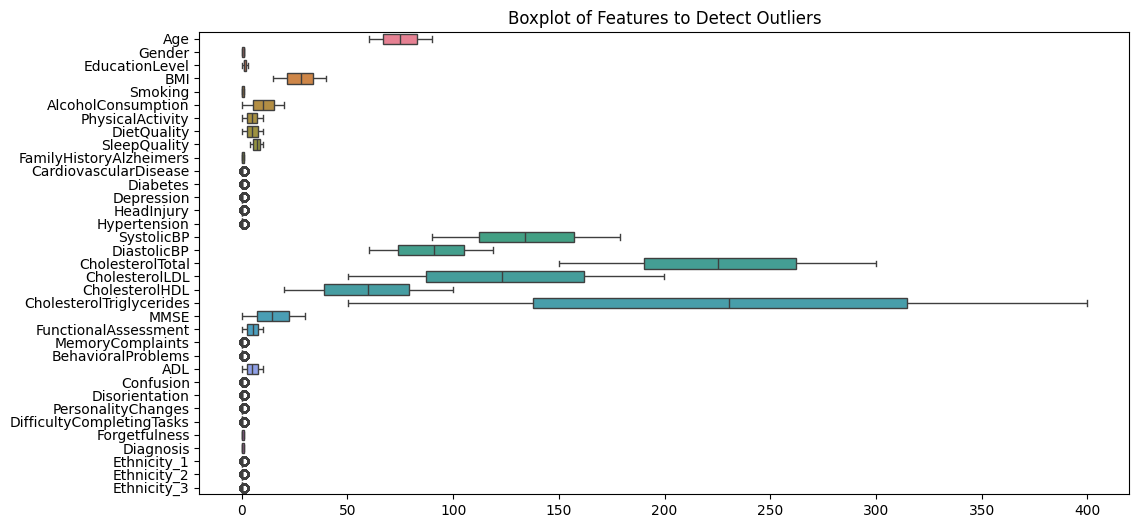

In [61]:
#Boxplot of all Features
plt.figure(figsize=(12, 6))
sns.boxplot(data=alz_data_class, orient="h")
plt.title("Boxplot of Features to Detect Outliers")

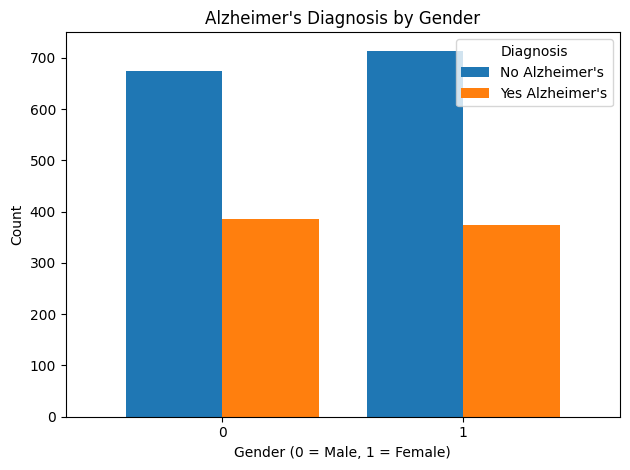

In [62]:
grouped_data = alz_data_class.groupby(['Gender', 'Diagnosis']).size().unstack(fill_value=0)
ax = grouped_data.plot(kind='bar', width=0.8)
ax.set_xlabel('Gender (0 = Male, 1 = Female)')
ax.set_ylabel('Count')
ax.set_title('Alzheimer\'s Diagnosis by Gender')
ax.legend(['No Alzheimer\'s', 'Yes Alzheimer\'s'], title='Diagnosis', loc='upper right')
plt.xticks(rotation="horizontal")
plt.tight_layout()

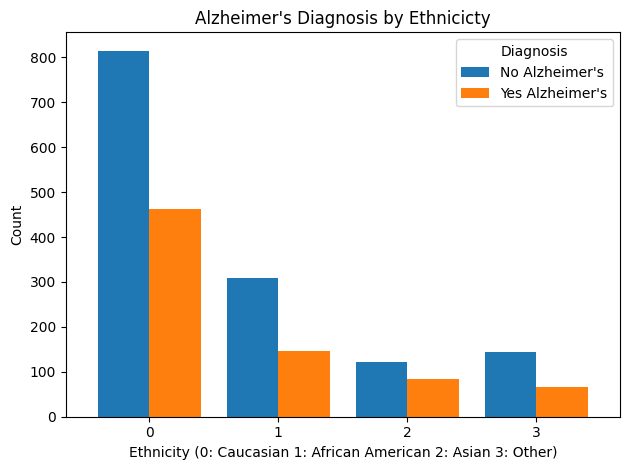

In [63]:
grouped_data = alz_data.groupby(['Ethnicity', 'Diagnosis']).size().unstack(fill_value=0)
ax = grouped_data.plot(kind='bar', width=0.8)
ax.set_xlabel('Ethnicity (0: Caucasian 1: African American 2: Asian 3: Other)')
ax.set_ylabel('Count')
ax.set_title('Alzheimer\'s Diagnosis by Ethnicicty')
ax.legend(['No Alzheimer\'s', 'Yes Alzheimer\'s'], title='Diagnosis', loc='upper right')
plt.xticks(rotation="horizontal")
plt.tight_layout()

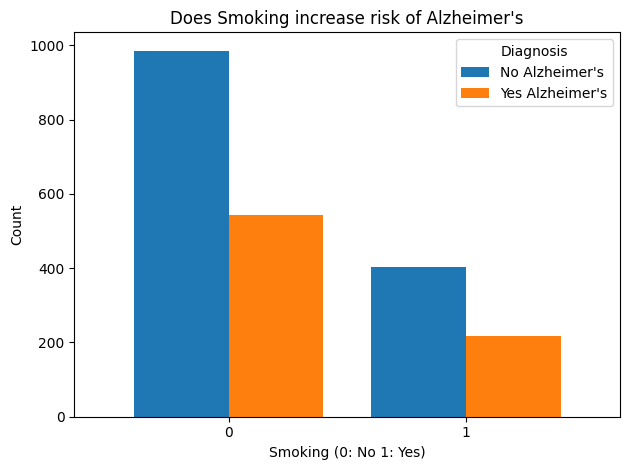

In [64]:
grouped_data = alz_data.groupby(['Smoking', 'Diagnosis']).size().unstack(fill_value=0)
ax = grouped_data.plot(kind='bar', width=0.8)
ax.set_xlabel('Smoking (0: No 1: Yes)')
ax.set_ylabel('Count')
ax.set_title('Does Smoking increase risk of Alzheimer\'s')
ax.legend(['No Alzheimer\'s', 'Yes Alzheimer\'s'], title='Diagnosis', loc='upper right')
plt.xticks(rotation="horizontal")
plt.tight_layout()

Text(0.5, 1.0, "Distribution of Alzheimer's Diagnosis")

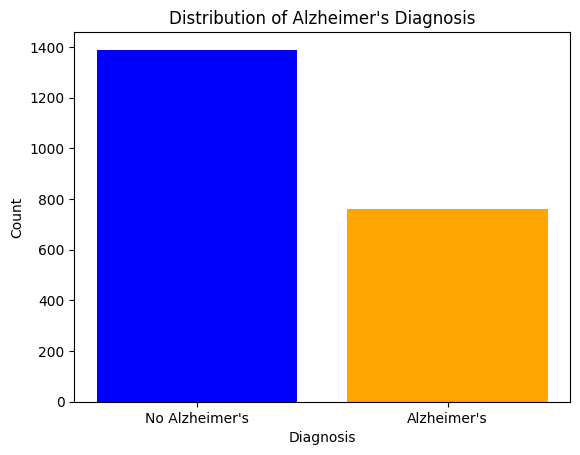

In [65]:
counts = alz_data_class['Diagnosis'].value_counts()
plt.bar(counts.index, counts.values, color=['blue', 'orange'])
plt.xticks([0, 1], ['No Alzheimer\'s', 'Alzheimer\'s'])
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Distribution of Alzheimer's Diagnosis")

# 2. Logistic Regression from Scratch

In [66]:
class LogisticRegressionScratch():
    def __init__(self, alpha=0.1, n_iter=10000):
        self.alpha = alpha
        self.n_iter = n_iter
        self.w = None
        self.b = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_cost(self, X, y):
        y_pred = self.sigmoid(np.dot(X, self.w) + self.b)
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)  # Avoid log(0) errors
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def compute_gradient(self, X, y):
        m = len(y)
        y_pred = self.sigmoid(np.dot(X, self.w) + self.b)
        dw = np.dot(X.T, (y_pred - y)) / m
        db = np.sum(y_pred - y) / m
        return dw, db

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0
        for _ in range(self.n_iter):
            dw, db = self.compute_gradient(X, y)
            self.w -= self.alpha * dw
            self.b -= self.alpha * db
        self.coef_ = self.w  # Add coef_ attribute for RFE compatibility
        return self

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def evaluate_classification(self,y_true, y_pred):
      TP = np.sum((y_true == 1) & (y_pred == 1))  # True Positives
      TN = np.sum((y_true==0)&(y_pred==0))  # True Negatives
      FP = np.sum((y_true==0)&(y_pred==1))  # False Positives
      FN = np.sum((y_true==1)&(y_pred==0))# False Negatives
      # Confusion matrix
      confusion_matrix = np.array([[TN, FP],
                                    [FN, TP]])
      # Precision, recall, and F1-score with safe handling of zero division
      precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
      recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
      f1_score = (precision*recall)/(precision+recall) if (precision+recall) > 0 else 0.0
      # Ensure metrics are floats
      precision = float(precision)
      recall = float(recall)
      f1_score = float(f1_score)
      return confusion_matrix, precision, recall, f1_score
    def get_params(self, deep=True):
        """Return hyperparameters for compatibility with scikit-learn."""
        return {"alpha": self.alpha, "n_iter": self.n_iter}

    def set_params(self, **params):
        """Set hyperparameters for compatibility with scikit-learn."""
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [67]:
def train_test_split_scratch(X, y, test_size=0.2, random_seed=42):
  np.random.seed(random_seed)
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices) # Shuffle the indices
  test_split_size = int(len(X) * test_size)
  test_indices = indices[:test_split_size]
  train_indices = indices[test_split_size:]
  X_train, X_test = X[train_indices], X[test_indices]
  y_train, y_test = y[train_indices], y[test_indices]
  return X_train, X_test, y_train, y_test

In [68]:
#Splitting target and feature variable
X=alz_data_class.drop(columns=['Diagnosis']).values
y=alz_data_class['Diagnosis'].values

In [69]:
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.2)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1720, 34)
Shape of X_test: (429, 34)
Shape of y_train: (1720,)
Shape of y_test: (429,)


In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [71]:
def LogisticRegressionScratchImplementation(alpha,n_iter):
    model=LogisticRegressionScratch(alpha=alpha,n_iter=n_iter)
    model.fit(X_train,y_train)
    y_test_pred=model.predict(X_test)
    y_train_pred=model.predict(X_train)
    print("For train set")
    confusion_matrix, precision, recall, f1_score=model.evaluate_classification(y_train,y_train_pred)
    print("Confusion matrix: ",confusion_matrix)
    print("Recall score: ",recall)
    print("Precision Score: ",precision)
    print("f1_score",f1_score)
    print("For test set")
    confusion_matrix, precision, recall, f1_score=model.evaluate_classification(y_test,y_test_pred)
    print("Confusion matrix: ",confusion_matrix)
    print("Recall score: ",recall)
    print("Precision Score: ",precision)
    print("f1_score",f1_score)
LogisticRegressionScratchImplementation(alpha=0.1,n_iter=1000)

For train set
Confusion matrix:  [[1008  105]
 [ 150  457]]
Recall score:  0.7528830313014827
Precision Score:  0.8131672597864769
f1_score 0.3909324208725406
For test set
Confusion matrix:  [[247  29]
 [ 44 109]]
Recall score:  0.7124183006535948
Precision Score:  0.7898550724637681
f1_score 0.3745704467353952


# 3. Random Forest Classifier

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [73]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [74]:
# Train set evaluation
print("For train set")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("Precision Score:", precision_score(y_train, y_train_pred))
print("Recall Score:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))
# Test set evaluation
print("For test set")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Precision Score:", precision_score(y_test, y_test_pred))
print("Recall Score:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

For train set
Confusion Matrix:
 [[1113    0]
 [   0  607]]
Precision Score: 1.0
Recall Score: 1.0
F1 Score: 1.0
For test set
Confusion Matrix:
 [[271   5]
 [ 26 127]]
Precision Score: 0.9621212121212122
Recall Score: 0.8300653594771242
F1 Score: 0.8912280701754386


# 4. Hyper-parameter Optimization using Cross-Validation

In [75]:
from sklearn.model_selection import RandomizedSearchCV

## For Logisitic Regression from Scratch

In [76]:
param_distributions = {
    'alpha': np.logspace(-4, -1, 10),
    'n_iter': range(5000, 50000, 5000)
}
random_search_LR = RandomizedSearchCV(
    estimator=LogisticRegressionScratch(),
    param_distributions=param_distributions,
    n_iter=10,  # Number of random combinations to test
    cv=5,  # Cross-validation with 5 splits
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search_LR.fit(X_train,y_train)
print(f"Best Hyperparameters: {random_search_LR.best_params_}")
print(f"Best Score: {random_search_LR.best_score_}")

Best Hyperparameters: {'n_iter': 25000, 'alpha': 0.002154434690031882}
Best Score: 0.7693975771375556


## For Random Forest Classifier

In [77]:
param_distributions = {
    'n_estimators': np.arange(50, 500, 50),  # Number of trees
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples per leaf
    'max_features': [None, 'sqrt', 'log2'],  # Number of features per split
    'bootstrap': [True, False]  # Whether to bootstrap samples
}
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,  # 5-fold cross-validation
    scoring='f1',
    random_state=42,
    n_jobs=-1  # Use all CPU cores for faster execution
)
random_search_rf.fit(X_train, y_train)
print(f"Best Hyperparameters: {random_search_rf.best_params_}")
print(f"Best Score: {random_search_rf.best_score_}")

Best Hyperparameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 50, 'bootstrap': True}
Best Score: 0.9262955486318939


# 5. Feature Selection

In [78]:
from sklearn.feature_selection import RFE

## For Logistic Regression

In [79]:
logreg_model=LogisticRegressionScratch()
rfe_LR=RFE(estimator=logreg_model,n_features_to_select=20)
X_train_selected_LR = rfe_LR.fit_transform(X_train, y_train)
X_test_selected_LR = rfe_LR.transform(X_test)
print("Selected Features: ", rfe_LR.support_)
print("Ranking of features: ",rfe_LR.ranking_)

Selected Features:  [ True False  True False  True False  True  True  True False False  True
  True  True False False  True False  True  True  True  True  True  True
  True  True  True False False False False  True False False]
Ranking of features:  [ 1  4  1  9  1 10  1  1  1  5 11  1  1  1  2 12  1 14  1  1  1  1  1  1
  1  1  1 13  8 15  6  1  3  7]


In [80]:
selected_features_LR = alz_data_class.drop(columns=['Diagnosis']).columns[rfe_LR.support_]
print("Selected Features: ",selected_features_LR)

Selected Features:  Index(['Age', 'EducationLevel', 'Smoking', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'Diabetes', 'Depression', 'HeadInjury', 'DiastolicBP',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE',
       'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL',
       'Confusion', 'Ethnicity_1'],
      dtype='object')


## For Random Forest Classifier

In [81]:
rf_model=RandomForestClassifier()
rfe_RF=RFE(estimator=rf_model,n_features_to_select=20)
X_train_selected_RF = rfe_RF.fit_transform(X_train, y_train)
X_test_selected_RF = rfe_RF.transform(X_test)
print("Selected Features: ", rfe_RF.support_)
print("Ranking of features: ",rfe_RF.ranking_)

Selected Features:  [ True False  True  True False  True  True  True  True False False False
 False False False  True  True  True  True  True  True  True  True  True
  True  True False False False False  True  True False False]
Ranking of features:  [ 1  2  1  1  6  1  1  1  1  5 11 12  4 13  3  1  1  1  1  1  1  1  1  1
  1  1  8  9 10  7  1  1 15 14]


In [82]:
selected_features_RF = alz_data_class.drop(columns=['Diagnosis']).columns[rfe_RF.support_]
print("Selected Features: ",selected_features_RF)

Selected Features:  Index(['Age', 'EducationLevel', 'BMI', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Forgetfulness',
       'Ethnicity_1'],
      dtype='object')


# 6. Final Model

## Logistic Regression from Scratch

In [83]:
best_alpha = random_search_LR.best_params_['alpha']
best_n_iter = random_search_LR.best_params_['n_iter']
final_logreg_model = LogisticRegressionScratch(alpha=best_alpha, n_iter=best_n_iter)
final_logreg_model.fit(X_train_selected_LR, y_train)
y_pred_test_final = final_logreg_model.predict(X_test_selected_LR)
y_pred_train_final = final_logreg_model.predict(X_train_selected_LR)
print('For train set')
conf_matrix, precision, recall, f1 = final_logreg_model.evaluate_classification(y_train, y_pred_train_final)
print("Final Model Performance on Test Set:")
print("Confusion Matrix:\n", conf_matrix)
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print('\nFor test set')
conf_matrix, precision, recall, f1 = final_logreg_model.evaluate_classification(y_test, y_pred_test_final)
print("Final Model Performance on Test Set:")
print("Confusion Matrix:\n", conf_matrix)
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

For train set
Final Model Performance on Test Set:
Confusion Matrix:
 [[1008  105]
 [ 148  459]]
Precision Score: 0.8138
Recall Score: 0.7562
F1 Score: 0.3920

For test set
Final Model Performance on Test Set:
Confusion Matrix:
 [[249  27]
 [ 44 109]]
Precision Score: 0.8015
Recall Score: 0.7124
F1 Score: 0.3772


# Random Forest Classifier

In [84]:
final_rf_model=RandomForestClassifier(**random_search_rf.best_params_)
final_rf_model.fit(X_train_selected_RF, y_train)
y_pred_train_final = final_rf_model.predict(X_train_selected_RF)
y_pred_test_final = final_rf_model.predict(X_test_selected_RF)
print('For train set:')
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train_final))
print(f"Precision Score: {precision_score(y_train, y_pred_train_final):.4f}")
print(f"Recall Score: {recall_score(y_train, y_pred_train_final):.4f}")
print(f"F1 Score: {f1_score(y_train, y_pred_train_final):.4f}")
print('\nFor test set:')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test_final))
print(f"Precision Score: {precision_score(y_test, y_pred_test_final):.4f}")
print(f"Recall Score: {recall_score(y_test, y_pred_test_final):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_test_final):.4f}")

For train set:
Confusion Matrix:
 [[1081   32]
 [  42  565]]
Precision Score: 0.9464
Recall Score: 0.9308
F1 Score: 0.9385

For test set:
Confusion Matrix:
 [[269   7]
 [ 13 140]]
Precision Score: 0.9524
Recall Score: 0.9150
F1 Score: 0.9333
